In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from datetime import datetime, timedelta

In [2]:
df = pd.read_excel("Scats Data October 2006.xls", sheet_name='Data')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Columns: 106 entries, SCATS Number to V95
dtypes: datetime64[ns](1), float64(2), int64(101), object(2)
memory usage: 3.4+ MB


In [4]:
df = df.drop(['SCATS Number', 'CD_MELWAY', 'NB_LATITUDE',
              'NB_LONGITUDE', 'HF VicRoads Internal',
              'VR Internal Stat', 'VR Internal Loc', 'NB_TYPE_SURVEY'], axis=1)
df.head()

,Location,Date,V00,V01,V02,V03,V04,V05,V06,V07,...,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,WARRIGAL_RD N of HIGH STREET_RD,2006-10-01 00:15:00,86,83,52,58,59,44,31,37,...,114,97,97,66,81,50,59,47,29,34
1,WARRIGAL_RD N of HIGH STREET_RD,2006-10-02 00:15:00,32,28,17,11,7,11,6,15,...,111,102,107,114,80,60,62,48,44,26
2,WARRIGAL_RD N of HIGH STREET_RD,2006-10-03 00:15:00,26,32,21,14,10,12,13,10,...,130,132,114,86,93,90,73,57,29,40
3,WARRIGAL_RD N of HIGH STREET_RD,2006-10-04 00:15:00,32,22,28,13,16,8,14,10,...,115,113,132,101,113,90,78,66,52,44
4,WARRIGAL_RD N of HIGH STREET_RD,2006-10-05 00:15:00,40,39,21,11,16,9,15,15,...,171,120,116,113,99,91,61,55,49,36


In [5]:
loc = df['Location'].unique()
print("Locations found:", loc)

Locations found: ['WARRIGAL_RD N of HIGH STREET_RD' 'HIGH STREET_RD E of WARRIGAL_RD'
 'WARRIGAL_RD S of HIGH STREET_RD' 'HIGH STREET_RD W of WARRIGAL_RD'
 'WARRIGAL_RD N of TOORAK_RD' 'BURWOOD_HWY E of WARRIGAL_RD'
 'WARRIGAL_RD S of BURWOOD_HWY' 'TOORAK_RD W of WARRIGAL_RD'
 'UNION_RD N of MAROONDAH_HWY' 'MAROONDAH_HWY E of UNION_RD'
 'UNION_RD S of MAROONDAH_HWY' 'MAROONDAH_HWY W of UNION_RD'
 'EARL_ST SE of PRINCESS_ST' 'PRINCESS_ST S of CHANDLER_HWY'
 'BURKE_RD S of EASTERN_FWY' 'BULLEEN_RD N of THOMPSONS_RD'
 'OFFRAMP_EASTERN_FWY E of BULLEEN_RD'
 'BULLEEN_RD S of EASTERN_FWY_W_BD_RAMPS'
 'OFFRAMP_EASTERN_FWY W of BULLEEN_RD' 'S.E.ARTERIAL N OF HIGH_ST'
 'HIGH_ST E OF S.E.ARTERIAL' 'HIGH_ST W OF WILLS_ST'
 'WILLS_ST NW OF HIGH_ST' 'HIGH_ST NE of BARKERS_RD'
 'BARKERS_RD E of HIGH_ST' 'CHURCH_ST SW of BARKERS_RD'
 'BARKERS_RD W of CHURCH_ST' 'DENMARK_ST N of BARKERS_RD'
 'BARKERS_RD E of DENMARK_ST' 'POWER_ST S of BARKERS_RD'
 'BARKERS_RD W of DENMARK_ST' 'BURKE_RD N of CANTERBURY

In [6]:
df_0 = df[df['Location'] == loc[1]].copy()

In [7]:
df_0['Date'] = pd.to_datetime(df_0['Date'])
df_0['day']         = df_0['Date'].dt.day
df_0['month']       = df_0['Date'].dt.month
df_0['year']        = df_0['Date'].dt.year
df_0['day_of_week'] = df_0['Date'].dt.dayofweek

In [8]:
x_feat = df_0[['day', 'month', 'year', 'day_of_week']]
y_all  = df_0.drop(['day', 'month', 'year', 'day_of_week', 'Location', 'Date'], axis=1)
y      = y_all.iloc[:, 0]          # time_index = 0  →  00:00

In [9]:
# Add lag features (following regress.py)
x_feat = x_feat.copy()
x_feat['y_lag1'] = y.shift(1)
x_feat['y_lag2'] = y.shift(2)

Prepare sequences for LSTM

In [10]:
# Drop the two NaN rows introduced by lagging, then align
x_feat = x_feat.dropna()
y_aligned = y.loc[x_feat.index]

In [11]:
# 80/20 split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x_feat, y_aligned, train_size=0.8, random_state=42, shuffle=False
)

In [12]:
# Scale features and target independently
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train_sc = scaler_x.fit_transform(x_train_raw)
x_test_sc  = scaler_x.transform(x_test_raw)

y_train_sc = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
y_test_sc  = scaler_y.transform(y_test_raw.values.reshape(-1, 1))

In [13]:
# Reshape to 3-D tensor: (samples, timesteps=1, features)
# LSTM expects [batch, timesteps, features]; we treat each row as 1 timestep.
x_train_lstm = x_train_sc.reshape(x_train_sc.shape[0], 1, x_train_sc.shape[1])
x_test_lstm  = x_test_sc.reshape(x_test_sc.shape[0],  1, x_test_sc.shape[1])

Build LSTM model

In [14]:
n_features = x_train_lstm.shape[2]

model = Sequential([
    LSTM(64, input_shape=(1, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)                        # single regression output
])

model.compile(optimizer='adam', loss='mse')
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    x_train_lstm, y_train_sc,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.2110 - val_loss: 0.0246
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2047 - val_loss: 0.0226
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1990 - val_loss: 0.0205
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1944 - val_loss: 0.0181
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1878 - val_loss: 0.0155
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1813 - val_loss: 0.0131
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1728 - val_loss: 0.0109
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1627 - val_loss: 0.0089
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1597 - val_loss: 0.0072
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1519 - val_loss: 0.0058
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1444 - val_loss: 0.0049
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1367 - val_l

Evaluate by obtaining RMSE and NRMSE

In [15]:
y_pred_sc = model.predict(x_test_lstm)
y_pred    = scaler_y.inverse_transform(y_pred_sc).flatten()
y_test    = y_test_raw.values

rmse  = root_mean_squared_error(y_test, y_pred)
nrmse = rmse / np.mean(y_test)

print(f"RMSE:  {rmse:.2f}")
print(f"NRMSE: {nrmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
RMSE:  11.56
NRMSE: 0.62


Visualization Evaluations

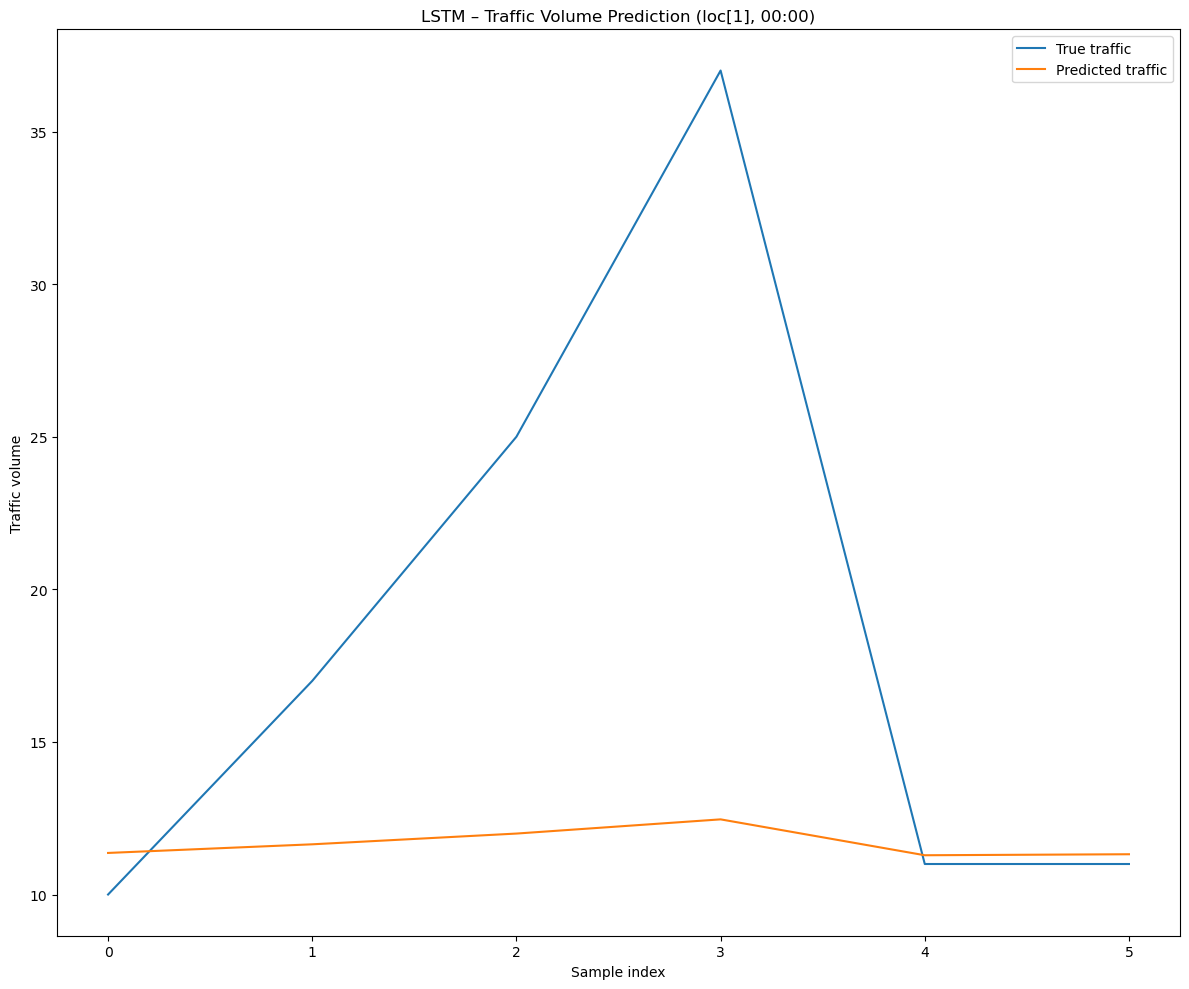

In [16]:
plt.figure(1, figsize=(12, 10))
plt.plot(range(len(y_test)), y_test,  label='True traffic')
plt.plot(range(len(y_test)), y_pred,  label='Predicted traffic')
plt.title('LSTM – Traffic Volume Prediction (loc[1], 00:00)')
plt.xlabel('Sample index')
plt.ylabel('Traffic volume')
plt.legend()
plt.tight_layout()
plt.savefig("lstm_prediction_plot.png", dpi=150)
plt.show()

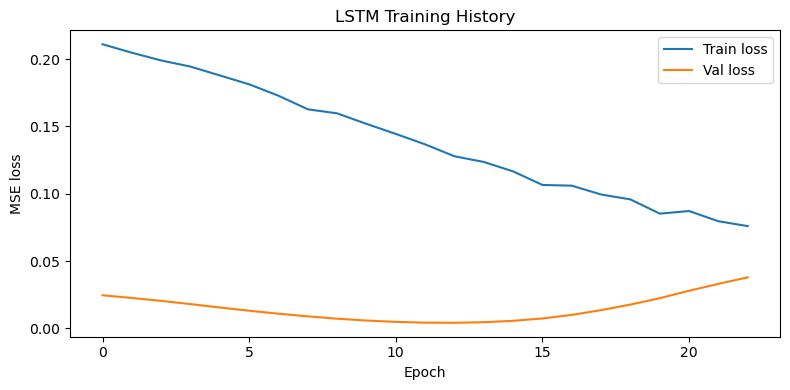

In [17]:
#Training loss curve
plt.figure(2, figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.tight_layout()
plt.savefig("lstm_training_loss.png", dpi=150)
plt.show()

Reusable condensed Prediction Function to use in a py file

In [18]:
def traffic_lstm(predict_day: str, loc_index: int, time_index: int):
    """
    Predict traffic volume for a given day, location, and time slot using LSTM.

    Parameters
    ----------
    predict_day : str   – target date as "MM/DD/YYYY"
    loc_index   : int   – index into df['Location'].unique()
    time_index  : int   – column index of the 15-min interval (0 = 00:00)

    Returns
    -------
    float – predicted traffic volume (inverse-scaled)
    """
    # Load & filter data 
    _df = pd.read_excel("Scats Data October 2006.xls", sheet_name='Data')
    _df = _df.drop(['SCATS Number', 'CD_MELWAY', 'NB_LATITUDE',
                    'NB_LONGITUDE', 'HF VicRoads Internal',
                    'VR Internal Stat', 'VR Internal Loc', 'NB_TYPE_SURVEY'], axis=1)

    _loc  = _df['Location'].unique()
    _df_0 = _df[_df['Location'] == _loc[loc_index]].copy()

    _df_0['Date']        = pd.to_datetime(_df_0['Date'])
    _df_0['day']         = _df_0['Date'].dt.day
    _df_0['month']       = _df_0['Date'].dt.month
    _df_0['year']        = _df_0['Date'].dt.year
    _df_0['day_of_week'] = _df_0['Date'].dt.dayofweek

    _x = _df_0[['day', 'month', 'year', 'day_of_week']].copy()
    _y = _df_0.drop(['day', 'month', 'year', 'day_of_week', 'Location', 'Date'], axis=1)
    _y = _y.iloc[:, time_index]

    _x['y_lag1'] = _y.shift(1)
    _x['y_lag2'] = _y.shift(2)
    _x = _x.dropna()
    _y = _y.loc[_x.index]

    # Train/test split (same 80/20, no shuffle)
    _x_train, _x_test, _y_train, _y_test = train_test_split(
        _x, _y, train_size=0.8, random_state=42, shuffle=False
    )

    # Scale
    _sx, _sy = MinMaxScaler(), MinMaxScaler()
    _x_tr_sc = _sx.fit_transform(_x_train)
    _y_tr_sc = _sy.fit_transform(_y_train.values.reshape(-1, 1))

    _x_tr_3d = _x_tr_sc.reshape(_x_tr_sc.shape[0], 1, _x_tr_sc.shape[1])

    # Build & train
    _n = _x_tr_3d.shape[2]
    _m = Sequential([
        LSTM(64, input_shape=(1, _n), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    _m.compile(optimizer='adam', loss='mse')
    _es = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    _m.fit(_x_tr_3d, _y_tr_sc, epochs=100, batch_size=16,
           callbacks=[_es], verbose=0)

    # ── Build the new-day feature row (same lag strategy as regress.py) ──────
    today     = datetime.strptime(predict_day, "%m/%d/%Y")
    yesterday = today - timedelta(days=1)
    before    = today - timedelta(days=2)

    dow_y = yesterday.weekday()
    dow_b = before.weekday()

    lag1 = float(np.mean(_y_train[_x_train['day_of_week'] == dow_y]))
    lag2 = float(np.mean(_y_train[_x_train['day_of_week'] == dow_b]))

    x_new = pd.DataFrame([{
        'day':         today.day,
        'month':       today.month,
        'year':        today.year,
        'day_of_week': today.weekday(),
        'y_lag1':      lag1,
        'y_lag2':      lag2,
    }])

    x_new_sc  = _sx.transform(x_new)
    x_new_3d  = x_new_sc.reshape(1, 1, x_new_sc.shape[1])

    pred_sc = _m.predict(x_new_3d, verbose=0)
    pred    = _sy.inverse_transform(pred_sc).flatten()
    return pred

In [19]:
if __name__ == "__main__":
    result = traffic_lstm("10/15/2006", loc_index=1, time_index=0)
    print(f"\nPredicted traffic volume for 10/15/2006: {result[0]:.1f}")


Predicted traffic volume for 10/15/2006: 28.4
